# Otomobil piyasası hacim yönü: 1 ay ve 3 ay karşılaştırması

Bu defter yalnız `noter_devir_otomobil_adet` serisini kullanır. Yıllık/YoY karşılaştırma **yoktur**. Frekans her iki deneyde de aylıktır; değişen yalnız tahmin ufkudur.

Karar ayı $t$ ve otomobil devir hacmi $V_t$ olmak üzere sürekli hedefler:

$$r_t^{(1)}=\ln(V_{t+1}/V_t), \qquad r_t^{(3)}=\ln(V_{t+3}/V_t)$$

Pozitif değer hedef ayda hacim artışı, negatif değer azalış, mutlak değerin büyümesi daha kuvvetli hareket demektir. Üç aylık hedef üç aylık toplam değil, başlangıç ayından üçüncü aya uçtan uca değişimdir. Tam yüzde değişim $100(e^r-1)$; üç aylık hareketin aylık bileşik eşdeğeri $100(e^{r/3}-1)$ ile hesaplanır.

Model ham hacmi tahmin eder. Log-değişim ve isteğe bağlı $[-1,1]$ gösterge skoru tahminden sonra üretilir. Böylece AutoGluon MASE metriği doğal araç-adedi ölçeğinde kalır.

In [1]:
from pathlib import Path
import importlib.util
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
SEASONAL_PERIOD = 12
INITIAL_TRAIN_MONTHS = 60
RUN_AUTOGLUON = False  # AutoGluon kurulduktan sonra True yapın
AUTOGLUON_TIME_LIMIT = 60
AUTOGLUON_MAX_ORIGINS = 6  # Önce küçük deneme; tam koşu için None
AUTOGLUON_AVAILABLE = importlib.util.find_spec('autogluon') is not None
print('Python:', sys.version.split()[0])
print('AutoGluon hazır mı:', AUTOGLUON_AVAILABLE)

Python: 3.12.7
AutoGluon hazır mı: False


## Veri yükleme ve değişmez bütünlük kontrolleri

2015–2017 döneminde otomobile özgü sütun yapısal olarak boştur. Model penceresi ilk gerçek otomobil gözlemi olan 2018-01'de başlar; eksikler doldurulmaz ve aylık değerler günlük satırlara çoğaltılmaz.

In [2]:
candidates = [
    Path('../data/noter_devir/noter_devir_2015_bugun_aylik.csv'),
    Path('data/noter_devir/noter_devir_2015_bugun_aylik.csv'),
]
DATA_PATH = next((p.resolve() for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Noter devir CSV dosyası bulunamadı.')

raw = pd.read_csv(DATA_PATH, usecols=['referans_ayi', 'noter_devir_otomobil_adet'])
raw['timestamp'] = pd.to_datetime(raw['referans_ayi'], format='%Y-%m')
raw['target'] = pd.to_numeric(raw['noter_devir_otomobil_adet'], errors='coerce')
volume = raw.loc[raw['target'].notna(), ['timestamp', 'target']].sort_values('timestamp').reset_index(drop=True)

expected_index = pd.date_range(volume['timestamp'].min(), volume['timestamp'].max(), freq='MS')
assert not volume['timestamp'].duplicated().any(), 'Tekrarlanan ay bulundu.'
assert volume['timestamp'].tolist() == expected_index.tolist(), 'Aylık indeks kesintisiz değil.'
assert volume['target'].notna().all(), 'İç dönemde eksik hacim var.'
assert (volume['target'] > 0).all(), 'Sıfır veya negatif hacim var.'
assert len(volume) == 102, f'Beklenen 102 yerine {len(volume)} gözlem bulundu.'

display(pd.DataFrame({
    'ölçüm': ['ham aylık hacim', '1-ay label', '3-ay label'],
    'gözlem': [len(volume), len(volume)-1, len(volume)-3]
}))
print('Dönem:', volume['timestamp'].min().strftime('%Y-%m'), '→', volume['timestamp'].max().strftime('%Y-%m'))
print('Kaynak:', DATA_PATH)

,ölçüm,gözlem
0,ham aylık hacim,102
1,1-ay label,101
2,3-ay label,99


Dönem: 2018-01 → 2026-06
Kaynak: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler v2\data\noter_devir\noter_devir_2015_bugun_aylik.csv


In [3]:
def exact_percent(log_change):
    return 100 * np.expm1(log_change)

targets = volume.copy()
targets['r_1ay_geriye_bakan'] = np.log(targets['target'] / targets['target'].shift(1))
targets['r_3ay_geriye_bakan'] = np.log(targets['target'] / targets['target'].shift(3))
targets['pct_1ay'] = exact_percent(targets['r_1ay_geriye_bakan'])
targets['pct_3ay_kumulatif'] = exact_percent(targets['r_3ay_geriye_bakan'])
targets['pct_3ay_aylik_esdeger'] = 100 * np.expm1(targets['r_3ay_geriye_bakan'] / 3)

summary = pd.DataFrame({
    '1 ay': targets['r_1ay_geriye_bakan'].describe(),
    '3 ay': targets['r_3ay_geriye_bakan'].describe(),
})
display(summary)
print('1 ay pozitif/negatif:', (targets['r_1ay_geriye_bakan'] > 0).sum(), '/', (targets['r_1ay_geriye_bakan'] < 0).sum())
print('3 ay pozitif/negatif:', (targets['r_3ay_geriye_bakan'] > 0).sum(), '/', (targets['r_3ay_geriye_bakan'] < 0).sum())

,1 ay,3 ay
count,101.0000,99.0000
mean,0.0031,0.0074
std,0.2252,0.3206
min,-0.7718,-0.9971
25%,-0.1189,-0.1921
50%,0.0068,0.0217
75%,0.1074,0.1946
max,0.7060,1.1347


1 ay pozitif/negatif: 53 / 48
3 ay pozitif/negatif: 52 / 47


## $[-1,1]$ yorumlama skoru

Log-değişim doğal olarak sınırsızdır. İstenen bounded gösterge $u=\\tanh(r/s)$ ile üretilir. $s$, her backtest kesiminde yalnız eğitim dönemindeki log-değişimlerin robust ölçeğidir: $s=1.4826\\,MAD$. Merkez çıkarılmaz; böylece sıfır her zaman ‘hacim değişmedi’ anlamını korur. Bu skor model targetı değil, karar/raporlama katmanıdır.

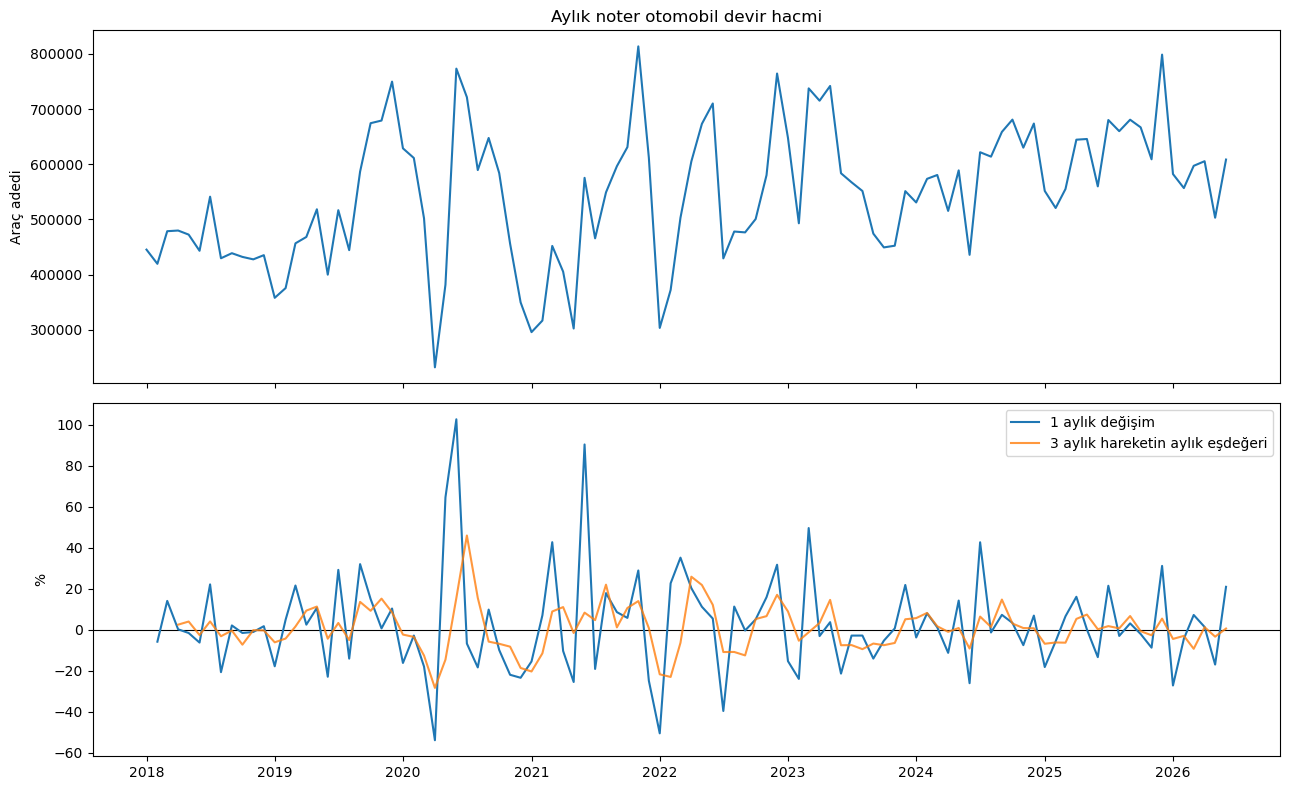

In [4]:
def robust_scale_train(log_changes, floor=1e-6):
    x = pd.Series(log_changes).dropna().to_numpy()
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return max(1.4826 * mad, floor)

def bounded_score(log_change, train_scale):
    return np.tanh(np.asarray(log_change) / train_scale)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(volume['timestamp'], volume['target'], color='#1f77b4')
axes[0].set_title('Aylık noter otomobil devir hacmi')
axes[0].set_ylabel('Araç adedi')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].plot(targets['timestamp'], targets['pct_1ay'], label='1 aylık değişim')
axes[1].plot(targets['timestamp'], targets['pct_3ay_aylik_esdeger'], label='3 aylık hareketin aylık eşdeğeri', alpha=0.8)
axes[1].set_ylabel('%')
axes[1].legend()
plt.tight_layout();

## Ortak rolling-origin backtest

İlk 60 ay eğitimdir. Her iki ufuk aynı karar aylarında değerlendirilir; son ortak karar ayı, üç aylık gerçekleşmesi bilinen 2026-03'tür. Böylece bir aylık yöntem daha fazla kolay örnek görerek avantaj kazanmaz. Baselinelar: değişim yok, mevsimsel-naive ve train-only log drift.

In [5]:
def seasonal_scale(train_values, m=12):
    x = np.asarray(train_values, dtype=float)
    if len(x) <= m:
        return np.nan
    return np.mean(np.abs(x[m:] - x[:-m]))

def baseline_backtest(df, initial_train=60, max_horizon=3):
    y = df['target'].to_numpy(float)
    dates = df['timestamp'].to_numpy()
    rows = []
    for origin in range(initial_train - 1, len(df) - max_horizon):
        train = y[:origin + 1]
        q = seasonal_scale(train, SEASONAL_PERIOD)
        scale_1 = robust_scale_train(np.diff(np.log(train)))
        scale_3 = robust_scale_train(np.log(train[3:] / train[:-3]))
        drift_per_month = (np.log(train[-1]) - np.log(train[0])) / (len(train) - 1)
        for h, score_scale in [(1, scale_1), (3, scale_3)]:
            actual_v = y[origin + h]
            actual_r = np.log(actual_v / train[-1])
            forecasts = {
                'DegisimYok': train[-1],
                'MevsimselNaive': y[origin + h - 12],
                'LogDrift': np.exp(np.log(train[-1]) + h * drift_per_month),
            }
            for model, pred_v in forecasts.items():
                pred_r = np.log(pred_v / train[-1])
                rows.append({
                    'origin': pd.Timestamp(dates[origin]), 'horizon': h, 'model': model,
                    'actual_volume': actual_v, 'pred_volume': pred_v,
                    'actual_r': actual_r, 'pred_r': pred_r,
                    'actual_score': float(bounded_score(actual_r, score_scale)),
                    'pred_score': float(bounded_score(pred_r, score_scale)),
                    'mase_component': abs(actual_v - pred_v) / q,
                })
    return pd.DataFrame(rows)

results = baseline_backtest(volume, INITIAL_TRAIN_MONTHS)
print('Ortak origin sayısı:', results['origin'].nunique())
print('İlk/son origin:', results['origin'].min().strftime('%Y-%m'), '/', results['origin'].max().strftime('%Y-%m'))
display(results.head())

Ortak origin sayısı: 40
İlk/son origin: 2022-12 / 2026-03


,origin,horizon,model,actual_volume,pred_volume,actual_r,pred_r,actual_score,pred_score,mase_component
0,2022-12-01,1,DegisimYok,"647,852.0000","764,329.0000",-0.1653,0.0000,-0.6514,0.0000,0.7579
1,2022-12-01,1,MevsimselNaive,"647,852.0000","303,354.0000",-0.1653,-0.9241,-0.6514,-0.9997,2.2415
2,2022-12-01,1,LogDrift,"647,852.0000","771,361.2562",-0.1653,0.0092,-0.6514,0.0431,0.8036
3,2022-12-01,3,DegisimYok,"737,443.0000","764,329.0000",-0.0358,0.0000,-0.1000,0.0000,0.1749
4,2022-12-01,3,MevsimselNaive,"737,443.0000","503,040.0000",-0.0358,-0.4183,-0.1000,-0.8250,1.5252


In [6]:
def direction_accuracy(actual, pred):
    return np.mean(np.sign(actual) == np.sign(pred))

def metric_table(result_df):
    rows = []
    for (h, model), g in result_df.groupby(['horizon', 'model']):
        rows.append({
            'ufuk_ay': h, 'model': model, 'n': len(g),
            'MASE_hacim': g['mase_component'].mean(),
            'MAE_arac': mean_absolute_error(g['actual_volume'], g['pred_volume']),
            'RMSE_arac': mean_squared_error(g['actual_volume'], g['pred_volume']) ** 0.5,
            'MAE_log_degisim': mean_absolute_error(g['actual_r'], g['pred_r']),
            'yon_dogrulugu': direction_accuracy(g['actual_r'], g['pred_r']),
            'score_MAE': mean_absolute_error(g['actual_score'], g['pred_score']),
        })
    return pd.DataFrame(rows).sort_values(['ufuk_ay', 'MASE_hacim'])

baseline_metrics = metric_table(results)
display(baseline_metrics)

,ufuk_ay,model,n,MASE_hacim,MAE_arac,RMSE_arac,MAE_log_degisim,yon_dogrulugu,score_MAE
0,1,DegisimYok,40,0.4683,"68,846.6750","94,056.0725",0.1153,0.0000,0.4257
1,1,LogDrift,40,0.4741,"69,716.0742","95,131.7252",0.1165,0.4500,0.4312
2,1,MevsimselNaive,40,0.6966,"103,549.2750","127,253.8222",0.1833,0.6500,0.4966
3,3,DegisimYok,40,0.5817,"86,242.2750","106,475.6043",0.1464,0.0000,0.3731
4,3,LogDrift,40,0.5931,"87,985.5371","110,205.3201",0.1484,0.5250,0.3788
5,3,MevsimselNaive,40,0.6537,"96,698.6750","115,885.8378",0.1656,0.6000,0.3765


## MASE nedir?

Aylık seri için eğitim ölçeği $Q_T=\\operatorname{mean}|V_s-V_{s-12}|$ olur. MASE, testteki mutlak tahmin hatasını bu ölçeğe böler:

$$MASE=\\operatorname{mean}(|V-\\hat V|/Q_T)$$

0 kusursuz tahmindir; 1 civarı hata, eğitim dönemindeki 12-ay mevsimsel-naive hatası ölçeğindedir; 1'den küçük daha iyidir. AutoGluon leaderboard hata metriklerini ‘yüksek daha iyi’ düzenine çevirmek için negatif gösterir: örneğin gerçek MASE 0.8 ise skor -0.8'dir. Üç adımlı AutoGluon iç skoru adım 1–3 ortalamasını kullanabildiğinden, yukarıdaki dış değerlendirme ayrıca yalnız $t+1$ ve $t+3$ endpoint hatalarını hesaplar.

## İsteğe bağlı AutoGluon rolling-origin deneyi

Aşağıdaki hücre varsayılan olarak kapalıdır. Paket otomatik kurulmaz. Önce az sayıda origin ile duman testi yapılmalı, ardından `AUTOGLUON_MAX_ORIGINS=None` ile ortak originlerin tamamı çalıştırılmalıdır. Tek `prediction_length=3` modeli hem $t+1$ hem $t+3$ tahmini üretir; dış tabloda iki endpoint ayrı değerlendirilir.

In [7]:
def run_autogluon_backtest(df, max_origins=6):
    if not AUTOGLUON_AVAILABLE:
        raise ImportError('AutoGluon kurulu değil. Bu ortamda otomatik kurulum yapılmadı.')
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

    origins = list(range(INITIAL_TRAIN_MONTHS - 1, len(df) - 3))
    if max_origins is not None:
        origins = origins[-max_origins:]
    rows = []
    model_root = Path('../outputs/autogluon_rolling').resolve()
    model_root.mkdir(parents=True, exist_ok=True)

    for origin in origins:
        cutoff = df.iloc[origin]['timestamp']
        train_df = df.iloc[:origin+1][['timestamp', 'target']].copy()
        train_df['item_id'] = 'noter_otomobil'
        ts = TimeSeriesDataFrame.from_data_frame(train_df, id_column='item_id', timestamp_column='timestamp')
        predictor = TimeSeriesPredictor(
            target='target', prediction_length=3, freq='MS', eval_metric='MASE',
            eval_metric_seasonal_period=12,
            path=str(model_root / cutoff.strftime('%Y_%m')),
            verbosity=1,
        )
        predictor.fit(
            ts, time_limit=AUTOGLUON_TIME_LIMIT, num_val_windows=2, val_step_size=1,
            hyperparameters={'Naive': {}, 'SeasonalNaive': {}, 'AutoETS': {}, 'Theta': {}, 'AutoARIMA': {}},
            enable_ensemble=True,
        )
        pred = predictor.predict(ts)
        point_col = 'mean'
        pred_values = pred.xs('noter_otomobil').iloc[:3][point_col].to_numpy(float)
        train_values = train_df['target'].to_numpy(float)
        q = seasonal_scale(train_values, 12)
        for h in [1, 3]:
            actual_v = float(df.iloc[origin+h]['target'])
            pred_v = float(pred_values[h-1])
            actual_r = np.log(actual_v / train_values[-1])
            pred_r = np.log(pred_v / train_values[-1]) if pred_v > 0 else np.nan
            r_train = np.diff(np.log(train_values)) if h == 1 else np.log(train_values[3:] / train_values[:-3])
            score_scale = robust_scale_train(r_train)
            rows.append({
                'origin': cutoff, 'horizon': h, 'model': 'AutoGluon',
                'actual_volume': actual_v, 'pred_volume': pred_v,
                'actual_r': actual_r, 'pred_r': pred_r,
                'actual_score': float(bounded_score(actual_r, score_scale)),
                'pred_score': float(bounded_score(pred_r, score_scale)) if np.isfinite(pred_r) else np.nan,
                'mase_component': abs(actual_v-pred_v)/q,
            })
    return pd.DataFrame(rows)

if RUN_AUTOGLUON:
    ag_results = run_autogluon_backtest(volume, AUTOGLUON_MAX_ORIGINS)
    combined = pd.concat([results, ag_results], ignore_index=True)
    display(metric_table(combined))
else:
    print('AutoGluon koşusu kapalı. RUN_AUTOGLUON=True yaparak etkinleştirin.')

AutoGluon koşusu kapalı. RUN_AUTOGLUON=True yaparak etkinleştirin.


## Sonuç okuma sözleşmesi

- 1-ay sonuçları taktik kısa dönem yönünü, 3-ay sonuçları daha yavaş fakat daha az gürültülü yönü temsil eder.
- Ufuklar farklı görevlerdir; MASE değerini tek başına karşılaştırıp ‘1 ay daha iyi’ denmez. Her ufuk kendi baseline'ına karşı değerlendirilir.
- Üç aylık log-değişim kümülatiftir. Büyüklük kıyasında `pct_3ay_aylik_esdeger` kullanılmalıdır.
- Yön doğruluğu tek başına model seçmez; MASE, araç-adedi MAE/RMSE ve bounded skor hatası birlikte okunur.
- Üç aylık targetlar örtüştüğü için 99 label, 99 bağımsız ekonomik şok anlamına gelmez. Duyarlılık analizinde her üçüncü origin ayrıca değerlendirilmelidir.
- Enflasyon hedefi mekanik olarak şişirmez; hedef TL fiyat değil araç adedidir. Enflasyon ileride yalnız yayımlanma gecikmesi korunmuş bir açıklayıcı değişken olarak eklenebilir.